# 📊 Logistic Regression (Manual vs Scikit-learn)

## Objective:
To understand Logistic Regression using both mathematical implementation and real-world datasets (study hours & sleep hours) to predict student performance.

## 📦 Importing Libraries  

Importing libraries for data processing, modeling, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

## 📈 Univariate Logistic Regression  

Using a single feature (Age) to understand the fundamentals of Logistic Regression.

In [4]:
data={
    "Age":[20,25,30,45,50],
    "y_true":[0,0,1,1,1]
}
df=pd.DataFrame(data)
df

,Age,y_true
0,20,0
1,25,0
2,30,1
3,45,1
4,50,1


## 🧮 Manual Logistic Regression  

Applying sigmoid function manually using predefined coefficients.
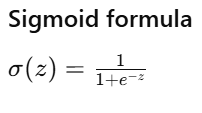
	​


## 📉 Log Loss Calculation  

Calculating model error using log loss.

In [5]:
m=0.06
c=-1.4
df["z"]=m*df["Age"]+c
df["y_pred_manual"]=1/(1+np.exp(-df["z"]))
#log_loss=-(y*log(y^))+(1-y)*(log(1-y^))
df["log_loss_manual"]=-(df["y_true"])*(np.log(df["y_pred_manual"]))+(1-df["y_true"])*(np.log(1-df["y_pred_manual"]))
df

,Age,y_true,z,y_pred_manual,log_loss_manual
0,20,0,-0.2,0.450166,-0.598139
1,25,0,0.1,0.524979,-0.744397
2,30,1,0.4,0.598688,0.513015
3,45,1,1.3,0.785835,0.241008
4,50,1,1.6,0.832018,0.183901


## 🤖 Logistic Regression using Scikit-learn  

Training model and comparing predictions with manual implementation.

In [8]:
X=df[["Age"]]
y=df["y_true"]
model=LogisticRegression()
model.fit(X,y)
df["y_model"]=model.predict_proba(X)[:,1]
log_loss_model=log_loss(y,df["y_model"])
df

,Age,y_true,z,y_pred_manual,log_loss_manual,y_model
0,20,0,-0.2,0.450166,-0.598139,0.004159
1,25,0,0.1,0.524979,-0.744397,0.137326
2,30,1,0.4,0.598688,0.513015,0.858518
3,45,1,1.3,0.785835,0.241008,0.999997
4,50,1,1.6,0.832018,0.183901,1.000000


## 📊 Visualization  

Comparing manual vs sklearn probability curves.

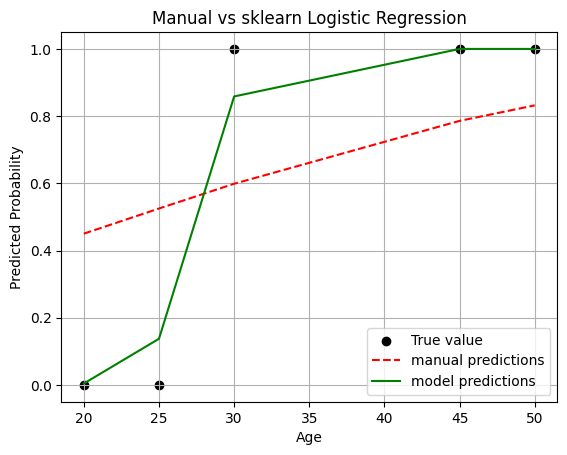

In [10]:
plt.scatter(df["Age"],df["y_true"],color="Black",label="True value")
plt.plot(df["Age"],df["y_pred_manual"],"r--",label="manual predictions")
plt.plot(df["Age"],df["y_model"],"g-",label="model predictions")
plt.xlabel("Age")
plt.ylabel("Predicted Probability")
plt.title("Manual vs sklearn Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

## 🎓 Student Performance Prediction  

Using real dataset with:
- Hours Studied  
- Hours Slept  
- Target: Pass/Fail  

## 📐 Multivariate Logistic Regression  

Using multiple features to improve prediction accuracy.

In [21]:
df=pd.read_csv("logistic_regression.csv")
df.info()
X=df[["Studied","Slept"]]
y=df["Passed"]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Studied  100 non-null    float64
 1   Slept    100 non-null    float64
 2   Passed   100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


## 🤖 Model Training  

Training logistic regression model on study & sleep data.


In [25]:

model=LogisticRegression(penalty=None, solver="lbfgs",max_iter=1000)
model.fit(X,y)
y


0     1
1     0
2     0
3     1
4     1
     ..
95    0
96    1
97    0
98    1
99    0
Name: Passed, Length: 100, dtype: int64

## 📈 Model Evaluation  

Evaluating performance using log loss.

In [34]:
y_pred=model.predict_proba(X)[:,1]
loss=log_loss(y,y_pred)
loss

0.2170079202987686

In [ ]:
c=model.intercept_[0]
m=model.coef_[0]

def sigmoid(z):
    return 1/(1+np.exp(-z))

z=c+m[0]*X.iloc[:,0]+m[1]*X.iloc[:,1]

p_sklearn = sigmoid(z)

log_loss_sklearn = -(y * np.log(p_sklearn) + (1 - y) * np.log(1 - p_sklearn))
avg_loss_sklearn = np.mean(log_loss_sklearn)
p_sklearn


0     0.998701
1     0.265360
2     0.000224
3     0.892612
4     0.999348
        ...   
95    0.000005
96    0.999716
97    0.097764
98    0.997298
99    0.001153
Length: 100, dtype: float64

In [35]:
import plotly.graph_objects as go
m0,m1,m2=-4,0.1,0.05

# 3D VISUALIZATION
age_range = np.linspace(20, 70, 50)
income_range = np.linspace(30, 100, 50)
Age_grid, Income_grid = np.meshgrid(age_range, income_range)

# Manual surface
Z_manual = m0 + m1 * Age_grid + m2 * Income_grid
P_manual = sigmoid(Z_manual)

# Sklearn surface
Z_sklearn = c + m[0] * Age_grid + m[1] * Income_grid
P_sklearn = sigmoid(Z_sklearn)


fig = go.Figure()

fig.add_trace(go.Surface(
    x=Age_grid,
    y=Income_grid,
    z=P_manual,
    colorscale='Reds',
    opacity=0.6,
    name='Manual Model'
))

fig.add_trace(go.Surface(
    x=Age_grid,
    y=Income_grid,
    z=P_sklearn,
    colorscale='Blues',
    opacity=0.6,
    name='Sklearn Model'
))

fig.add_trace(go.Scatter3d(
    x=X.iloc[:, 0],
    y=X.iloc[:, 1],
    z=y,
    mode='markers',
    marker=dict(size=6, color='black'),
    name='Actual Data'
))

fig.update_layout(
    title='Manual vs Sklearn Logistic Regression (Interactive 3D)',
    scene=dict(
        xaxis_title='Age',
        yaxis_title='Income',
        zaxis_title='Predicted Probability'
    ),
    legend=dict(x=0.05, y=0.95)
)

fig.show()